Import File

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/imdb.csv")
df.head()

,web_scraper_order,web_scraper_start_url,title,review,rating,likes,dislikes
0,1768461327-1,https://www.imdb.com/title/tt36642456/reviews/...,Simply impactful story telling,"Haq is a triumph, carried by its best assets: ...",9.0,37,3
1,1768461327-2,https://www.imdb.com/title/tt36642456/reviews/...,Bold and Brilliant Film Inspired by Real Events,Haq is a powerful movie inspired by the real-l...,9.0,21,2
2,1768461327-3,https://www.imdb.com/title/tt36642456/reviews/...,Haq se dekho,I might be a bit late to celebrate this incred...,9.0,24,3
3,1768461327-4,https://www.imdb.com/title/tt36642456/reviews/...,"Great movie, Simple yet impactful","I loved this movie , it really hit hard and ma...",10.0,30,5
4,1768461327-5,https://www.imdb.com/title/tt36642456/reviews/...,A must watch movie,Haq is a powerful portrayal of the real strugg...,10.0,15,2


**Install Transformer**

In [5]:
!pip install -q transformers datasets sentence-transformers accelerate

**Create Small Sample**

In [6]:
df = df.dropna(subset=['review'])
df["review"] = df["review"].astype(str)
df_demo = df.sample(n=20, random_state=42)

**Sentiment Analysis using Transformers (cardiffnlp/twitter-roberta-base-sentiment)**

In [8]:
label_map = {
    "LABEL_0": "Negative",
    "LABEL_1": "Neutral",
    "LABEL_2": "Positive",
}

In [10]:
from transformers import pipeline
sentiment = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment", return_all_scores= True)
df_demo["sentiment_scores"] = df_demo["review"].apply(lambda x:{label_map[item["label"]]:item["score"]
                                                                for item in sentiment(x[:512])[0]})
df_demo["dominant_sentiment"] = df_demo["sentiment_scores"].apply(lambda x: max(x, key=x.get))

Device set to use cpu
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [11]:
df_demo

,web_scraper_order,web_scraper_start_url,title,review,rating,likes,dislikes,sentiment_scores,dominant_sentiment
68,1768461327-69,https://www.imdb.com/title/tt36642456/reviews/...,A Reflection of Inner Strength,A Reflection of Inner Strength\nHaq celebrates...,10.0,1,1,"{'Negative': 0.003631971776485443, 'Neutral': ...",Positive
45,1768461327-46,https://www.imdb.com/title/tt36642456/reviews/...,"Bold, But Not Pathbreaking!",The Quiet Revolution: What Works\n\nSuparn S. ...,7.0,0,1,"{'Negative': 0.01784326881170273, 'Neutral': 0...",Positive
9,1768461327-10,https://www.imdb.com/title/tt36642456/reviews/...,HAQ review,Just watched HAQ in the theatres.\n\nSimply lo...,7.0,5,1,"{'Negative': 0.0034628775902092457, 'Neutral':...",Positive
76,1768461327-77,https://www.imdb.com/title/tt36642456/reviews/...,Truth in Every Frame,You can tell Haq comes from a place of truth. ...,10.0,1,1,"{'Negative': 0.002751881256699562, 'Neutral': ...",Positive
141,1768461327-142,https://www.imdb.com/title/tt36642456/reviews/...,Emotionally Intelligent and Deeply Human,What impressed me most was the emotional intel...,10.0,1,1,"{'Negative': 0.010974678210914135, 'Neutral': ...",Positive
108,1768461327-109,https://www.imdb.com/title/tt36642456/reviews/...,An Honest Slice of Humanity,What stands out in Haq is how human it feels. ...,10.0,1,1,"{'Negative': 0.008081755600869656, 'Neutral': ...",Positive
212,1768461327-213,https://www.imdb.com/title/tt36642456/reviews/...,Fantastic movie in this time,"""After watching poor-quality Bollywood movies ...",10.0,0,0,"{'Negative': 0.003851680550724268, 'Neutral': ...",Positive
237,1768461327-238,https://www.imdb.com/title/tt36642456/reviews/...,Its a must watch,"Stumbled upon this recent release, and thank g...",10.0,0,0,"{'Negative': 0.02929416298866272, 'Neutral': 0...",Positive
129,1768461327-130,https://www.imdb.com/title/tt36642456/reviews/...,A Story That Needed to Be Told,Haq brings to light a story that has lived in ...,10.0,1,1,"{'Negative': 0.024671301245689392, 'Neutral': ...",Positive
218,1768461327-219,https://www.imdb.com/title/tt36642456/reviews/...,Must Watch!!!,Haven't seen a masterpiece like this since a v...,10.0,0,0,"{'Negative': 0.01229787152260542, 'Neutral': 0...",Positive


**Perform Emotion Analysis "j-hartmann/emotion-english-distilroberta-base"**

In [12]:
emotion = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", return_all_scores=True)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [13]:
df_demo["emotion_scores"]= (df_demo["review"].apply(lambda x: {
    item["label"]:item["score"]
    for item in emotion(x[:512])[0]
}))

In [14]:
df_demo

,web_scraper_order,web_scraper_start_url,title,review,rating,likes,dislikes,sentiment_scores,dominant_sentiment,emotion_scores
68,1768461327-69,https://www.imdb.com/title/tt36642456/reviews/...,A Reflection of Inner Strength,A Reflection of Inner Strength\nHaq celebrates...,10.0,1,1,"{'Negative': 0.003631971776485443, 'Neutral': ...",Positive,"{'anger': 0.014237863942980766, 'disgust': 0.0..."
45,1768461327-46,https://www.imdb.com/title/tt36642456/reviews/...,"Bold, But Not Pathbreaking!",The Quiet Revolution: What Works\n\nSuparn S. ...,7.0,0,1,"{'Negative': 0.01784326881170273, 'Neutral': 0...",Positive,"{'anger': 0.05563565716147423, 'disgust': 0.04..."
9,1768461327-10,https://www.imdb.com/title/tt36642456/reviews/...,HAQ review,Just watched HAQ in the theatres.\n\nSimply lo...,7.0,5,1,"{'Negative': 0.0034628775902092457, 'Neutral':...",Positive,"{'anger': 0.005337706301361322, 'disgust': 0.0..."
76,1768461327-77,https://www.imdb.com/title/tt36642456/reviews/...,Truth in Every Frame,You can tell Haq comes from a place of truth. ...,10.0,1,1,"{'Negative': 0.002751881256699562, 'Neutral': ...",Positive,"{'anger': 0.0062131029553711414, 'disgust': 0...."
141,1768461327-142,https://www.imdb.com/title/tt36642456/reviews/...,Emotionally Intelligent and Deeply Human,What impressed me most was the emotional intel...,10.0,1,1,"{'Negative': 0.010974678210914135, 'Neutral': ...",Positive,"{'anger': 0.026384487748146057, 'disgust': 0.3..."
108,1768461327-109,https://www.imdb.com/title/tt36642456/reviews/...,An Honest Slice of Humanity,What stands out in Haq is how human it feels. ...,10.0,1,1,"{'Negative': 0.008081755600869656, 'Neutral': ...",Positive,"{'anger': 0.004785243887454271, 'disgust': 0.0..."
212,1768461327-213,https://www.imdb.com/title/tt36642456/reviews/...,Fantastic movie in this time,"""After watching poor-quality Bollywood movies ...",10.0,0,0,"{'Negative': 0.003851680550724268, 'Neutral': ...",Positive,"{'anger': 0.0012372387573122978, 'disgust': 0...."
237,1768461327-238,https://www.imdb.com/title/tt36642456/reviews/...,Its a must watch,"Stumbled upon this recent release, and thank g...",10.0,0,0,"{'Negative': 0.02929416298866272, 'Neutral': 0...",Positive,"{'anger': 0.0103608388453722, 'disgust': 0.004..."
129,1768461327-130,https://www.imdb.com/title/tt36642456/reviews/...,A Story That Needed to Be Told,Haq brings to light a story that has lived in ...,10.0,1,1,"{'Negative': 0.024671301245689392, 'Neutral': ...",Positive,"{'anger': 0.0030844593420624733, 'disgust': 0...."
218,1768461327-219,https://www.imdb.com/title/tt36642456/reviews/...,Must Watch!!!,Haven't seen a masterpiece like this since a v...,10.0,0,0,"{'Negative': 0.01229787152260542, 'Neutral': 0...",Positive,"{'anger': 0.007691914681345224, 'disgust': 0.0..."


**Manual Classification of Text "valhalla/distilbart-mnli-12-1"**

In [18]:
frames = [
    "gender justice",
    "religion reforms",
    "legal rights",
    "patriarchy and power",
    "artistic excellence",
    "social awareness",
    "emotional storytelling",
    "women empowernment"
]

frame_pipe = pipeline("zero-shot-classification",
                      model="valhalla/distilbart-mnli-12-1")

texts = df_demo["review"].str[:512].tolist()

results = frame_pipe(texts, candidate_labels=frames, batch_size=4)

df_demo["dominant_frame"] = [r["labels"][0] for r in results]

Device set to use cpu


In [19]:
df_demo

,web_scraper_order,web_scraper_start_url,title,review,rating,likes,dislikes,sentiment_scores,dominant_sentiment,emotion_scores,dominant_frame
68,1768461327-69,https://www.imdb.com/title/tt36642456/reviews/...,A Reflection of Inner Strength,A Reflection of Inner Strength\nHaq celebrates...,10.0,1,1,"{'Negative': 0.003631971776485443, 'Neutral': ...",Positive,"{'anger': 0.014237863942980766, 'disgust': 0.0...",emotional storytelling
45,1768461327-46,https://www.imdb.com/title/tt36642456/reviews/...,"Bold, But Not Pathbreaking!",The Quiet Revolution: What Works\n\nSuparn S. ...,7.0,0,1,"{'Negative': 0.01784326881170273, 'Neutral': 0...",Positive,"{'anger': 0.05563565716147423, 'disgust': 0.04...",artistic excellence
9,1768461327-10,https://www.imdb.com/title/tt36642456/reviews/...,HAQ review,Just watched HAQ in the theatres.\n\nSimply lo...,7.0,5,1,"{'Negative': 0.0034628775902092457, 'Neutral':...",Positive,"{'anger': 0.005337706301361322, 'disgust': 0.0...",artistic excellence
76,1768461327-77,https://www.imdb.com/title/tt36642456/reviews/...,Truth in Every Frame,You can tell Haq comes from a place of truth. ...,10.0,1,1,"{'Negative': 0.002751881256699562, 'Neutral': ...",Positive,"{'anger': 0.0062131029553711414, 'disgust': 0....",emotional storytelling
141,1768461327-142,https://www.imdb.com/title/tt36642456/reviews/...,Emotionally Intelligent and Deeply Human,What impressed me most was the emotional intel...,10.0,1,1,"{'Negative': 0.010974678210914135, 'Neutral': ...",Positive,"{'anger': 0.026384487748146057, 'disgust': 0.3...",artistic excellence
108,1768461327-109,https://www.imdb.com/title/tt36642456/reviews/...,An Honest Slice of Humanity,What stands out in Haq is how human it feels. ...,10.0,1,1,"{'Negative': 0.008081755600869656, 'Neutral': ...",Positive,"{'anger': 0.004785243887454271, 'disgust': 0.0...",emotional storytelling
212,1768461327-213,https://www.imdb.com/title/tt36642456/reviews/...,Fantastic movie in this time,"""After watching poor-quality Bollywood movies ...",10.0,0,0,"{'Negative': 0.003851680550724268, 'Neutral': ...",Positive,"{'anger': 0.0012372387573122978, 'disgust': 0....",emotional storytelling
237,1768461327-238,https://www.imdb.com/title/tt36642456/reviews/...,Its a must watch,"Stumbled upon this recent release, and thank g...",10.0,0,0,"{'Negative': 0.02929416298866272, 'Neutral': 0...",Positive,"{'anger': 0.0103608388453722, 'disgust': 0.004...",artistic excellence
129,1768461327-130,https://www.imdb.com/title/tt36642456/reviews/...,A Story That Needed to Be Told,Haq brings to light a story that has lived in ...,10.0,1,1,"{'Negative': 0.024671301245689392, 'Neutral': ...",Positive,"{'anger': 0.0030844593420624733, 'disgust': 0....",emotional storytelling
218,1768461327-219,https://www.imdb.com/title/tt36642456/reviews/...,Must Watch!!!,Haven't seen a masterpiece like this since a v...,10.0,0,0,"{'Negative': 0.01229787152260542, 'Neutral': 0...",Positive,"{'anger': 0.007691914681345224, 'disgust': 0.0...",artistic excellence


# Task
## Analyze the sentiment and key discussion themes of the movie reviews

Visualize the distribution of dominant sentiments (Positive, Neutral, Negative) and dominant frames (e.g., gender justice, artistic excellence) found in the `df_demo` DataFrame to understand the overall public opinion and the most frequently discussed topics in the reviews.

## Analyze Dominant Sentiment Distribution

### Subtask:
Calculate the distribution of 'dominant_sentiment' in the `df_demo` DataFrame to understand the overall sentiment of the reviews.


**Reasoning**:
I will calculate the value counts of the 'dominant_sentiment' column in the `df_demo` DataFrame to get the sentiment distribution.



In [20]:
sentiment_distribution = df_demo['dominant_sentiment'].value_counts()
print(sentiment_distribution)

dominant_sentiment
Positive    19
Neutral      1
Name: count, dtype: int64


**Reasoning**:
The sentiment distribution has been calculated; now, I will visualize it using a bar plot to provide a clear graphical representation of the sentiment breakdown.



/tmp/ipython-input-530330619.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='viridis')


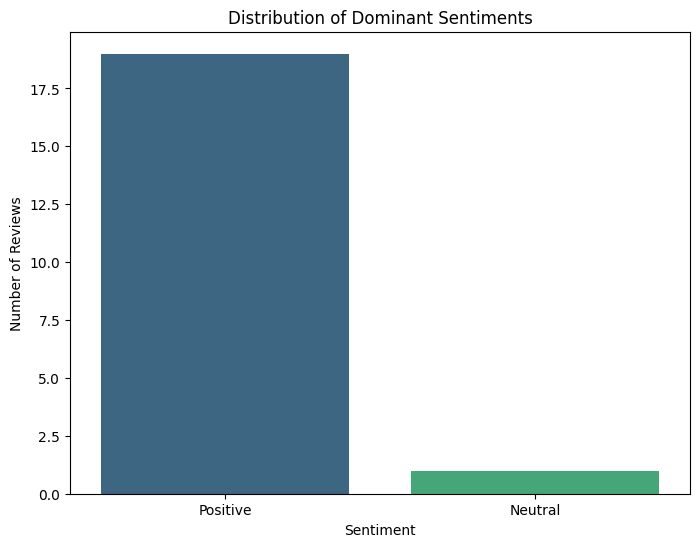

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_distribution.index, y=sentiment_distribution.values, palette='viridis')
plt.title('Distribution of Dominant Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()


**Reasoning**:
The previous code block produced a `FutureWarning` regarding the use of `palette` without `hue` in `seaborn.barplot`. To resolve this, I will explicitly set the `hue` argument to the x-axis variable and `legend=False` as suggested by the warning, ensuring cleaner code and preventing future deprecation issues.



**Reasoning**:
I have successfully calculated and visualized the distribution of dominant sentiments. Now, to address the second part of the main task, I will calculate the distribution of 'dominant_frame' in the `df_demo` DataFrame to understand the most frequently discussed topics.



In [23]:
frame_distribution = df_demo['dominant_frame'].value_counts()
print(frame_distribution)

dominant_frame
artistic excellence       11
emotional storytelling     9
Name: count, dtype: int64


**Reasoning**:
The distribution of dominant frames has been calculated. To visualize the most frequently discussed topics, I will now create a bar plot for the `frame_distribution`.



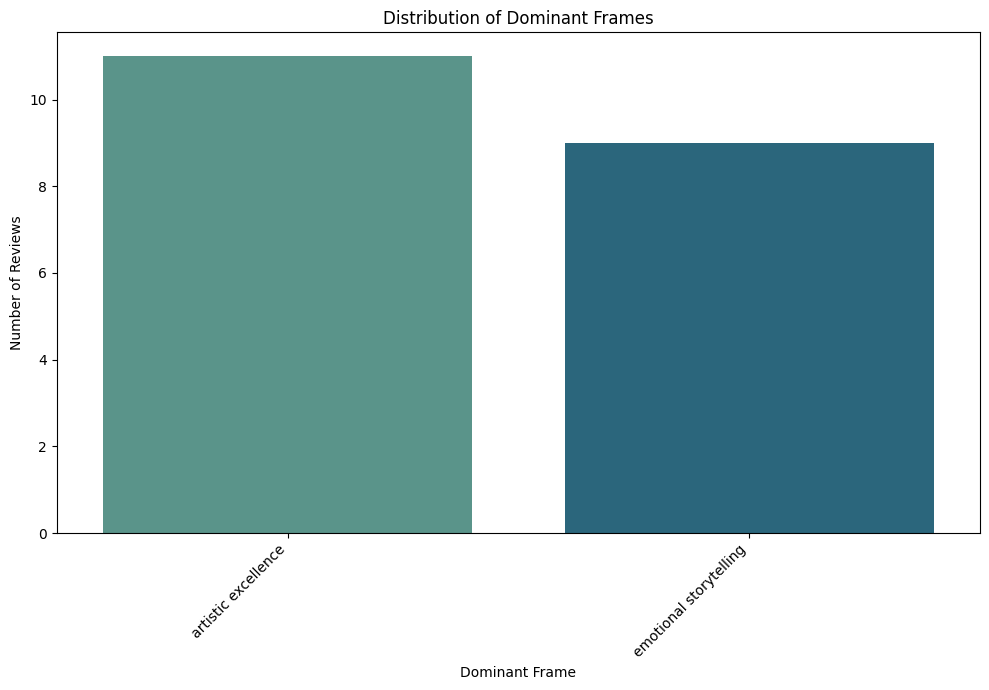

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.barplot(x=frame_distribution.index, y=frame_distribution.values, hue=frame_distribution.index, palette='crest', legend=False)
plt.title('Distribution of Dominant Frames')
plt.xlabel('Dominant Frame')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the findings from the sentiment and frame analysis, providing insights into public opinion and key discussion topics.


## Summary:

### Data Analysis Key Findings

*   The majority of the movie reviews analyzed are positive, with 19 reviews classified as 'Positive' and only 1 as 'Neutral'. No negative sentiments were found in the dataset.
*   The most frequently discussed themes (dominant frames) in the reviews are 'artistic excellence' with 11 instances, followed by 'emotional storytelling' with 9 instances.
*   Both the distribution of dominant sentiments and dominant frames were successfully calculated and visualized using bar plots.

### Insights or Next Steps

*   The overwhelmingly positive sentiment suggests high satisfaction among viewers, indicating the movie is well-received.
*   The prominence of 'artistic excellence' and 'emotional storytelling' as dominant frames highlights that these aspects are key drivers of audience engagement and critical appreciation. Future marketing could leverage these specific strengths.
